In [2]:
## Import Libraries
import pandas as pd
from textblob import TextBlob
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
### Load Data
df = pd.read_csv(r"your Cleaned_bit_usd_data.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df[['Close']]
df.head()

,Close
Date,
NaT,BTC-USD
2014-09-17,457.3340148925781
2014-09-18,424.4400024414063
2014-09-19,394.7959899902344
2014-09-20,408.9039916992188


In [7]:
## Percentage Returns
df['Close'] = df['Close'].replace(r'[\$,]', '', regex=True)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df['Close'].fillna(method='ffill', inplace=True)

df['returns'] = df['Close'].pct_change()
df.head()

C:\Users\anand\AppData\Local\Temp\ipykernel_10564\807810921.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Close'].fillna(method='ffill', inplace=True)
C:\Users\anand\AppData\Local\Temp\ipykernel_10564\807810921.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Close'].fillna(method='ffill', inplace=True)


,Close,returns
Date,,
NaT,NaN,NaN
2014-09-17,457.334015,NaN
2014-09-18,424.440002,-0.071926
2014-09-19,394.795990,-0.069843
2014-09-20,408.903992,0.035735


In [8]:
### 30- Days Rolling Volatility
df['volatility'] = df['returns'].rolling(window=30).std()
df.head()

,Close,returns,volatility
Date,,,
NaT,NaN,NaN,NaN
2014-09-17,457.334015,NaN,NaN
2014-09-18,424.440002,-0.071926,NaN
2014-09-19,394.795990,-0.069843,NaN
2014-09-20,408.903992,0.035735,NaN


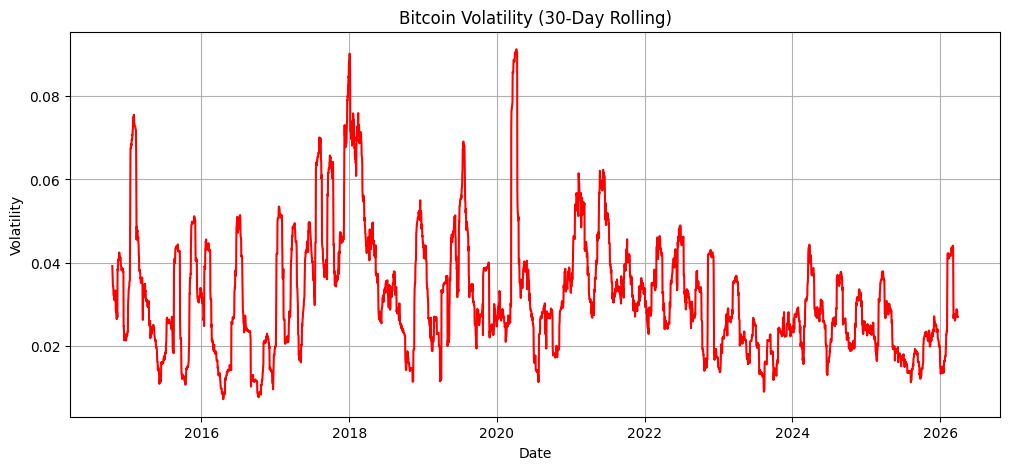

In [9]:
### Volatility Visualization
plt.figure(figsize=(12,5))
plt.plot(df.index, df['volatility'], color='red')
plt.title("Bitcoin Volatility (30-Day Rolling)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

In [10]:
#### Sentiment Analysis
###  Load the Social Media Data
news_data = [
    "Bitcoin price is rising rapidly, investors are excited",
    "Crypto market crashes causing panic among traders",
    "Bitcoin shows strong bullish trend",
    "Regulation fears impact cryptocurrency market negatively",
    "Investors optimistic about Bitcoin future"
]

news_df = pd.DataFrame(news_data, columns=['text'])
news_df.head()

,text
0,"Bitcoin price is rising rapidly, investors are..."
1,Crypto market crashes causing panic among traders
2,Bitcoin shows strong bullish trend
3,Regulation fears impact cryptocurrency market ...
4,Investors optimistic about Bitcoin future


In [11]:
news_df['sentiment'] = news_df['text'].apply(lambda x: TextBlob(x).sentiment.polarity)
news_df

,text,sentiment
0,"Bitcoin price is rising rapidly, investors are...",0.375000
1,Crypto market crashes causing panic among traders,0.000000
2,Bitcoin shows strong bullish trend,0.433333
3,Regulation fears impact cryptocurrency market ...,-0.300000
4,Investors optimistic about Bitcoin future,0.000000


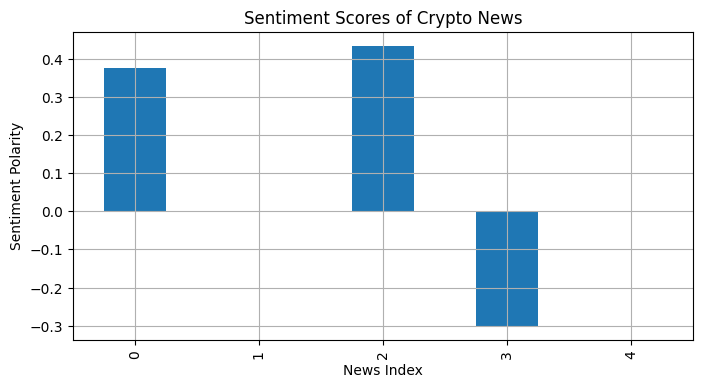

In [12]:
#### Sentiment Visualization
plt.figure(figsize=(8,4))
news_df['sentiment'].plot(kind='bar')
plt.title("Sentiment Scores of Crypto News")
plt.xlabel("News Index")
plt.ylabel("Sentiment Polarity")
plt.grid(True)
plt.show()

In [13]:
#### To Combine Volatility and Sentiment
# Average sentiment
avg_sentiment = news_df['sentiment'].mean()

print("Average Market Sentiment:", avg_sentiment)

# Add sentiment to dataframe
df['avg_sentiment'] = avg_sentiment

df[['volatility', 'avg_sentiment']].tail()

Average Market Sentiment: 0.10166666666666666


,volatility,avg_sentiment
Date,,
2026-03-24,0.028743,0.101667
2026-03-25,0.027391,0.101667
2026-03-26,0.028229,0.101667
2026-03-27,0.026868,0.101667
2026-03-29,0.026871,0.101667


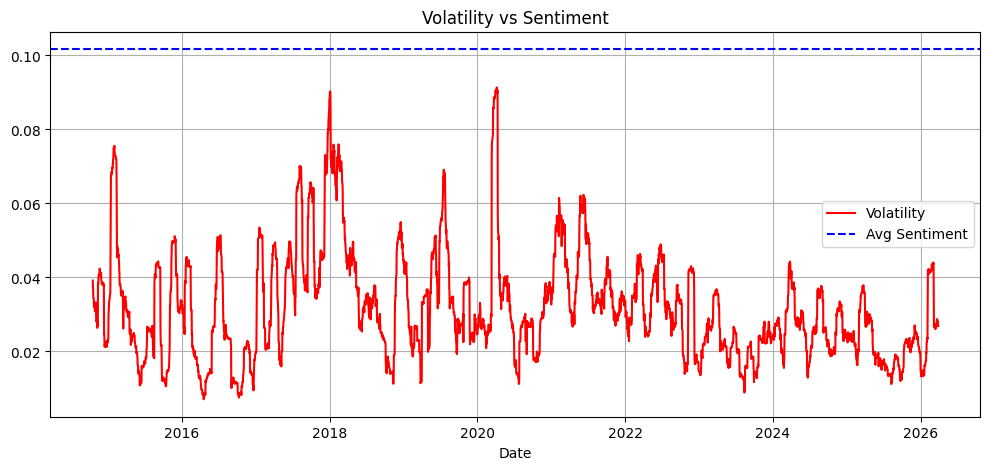

In [14]:
#### Volatility and Sentiment Visualization
plt.figure(figsize=(12,5))

plt.plot(df.index, df['volatility'], label='Volatility', color='red')
plt.axhline(y=avg_sentiment, color='blue', linestyle='--', label='Avg Sentiment')

plt.title("Volatility vs Sentiment")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()